# Task 4: Ensemble Learning

**Objective:** Implement ensemble models to predict video game success and evaluate the impact of including unsupervised cluster labels as a feature.
**Required Inputs:** `../data/clustered.csv`, `../models/supervised_best.pkl`
**Outputs Produced:** Final performance figures in `../reports/`

**Strategy:**
I will implement two ensemble methods: **Random Forest** (Bagging) and **XGBoost** (Boosting). I will then compare their performance against the Logistic Regression baseline from Task 2. Crucially, I am now including `cluster_label` as a categorical feature to see if the patterns found in Task 3 improve the model's predictive power.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

CLUSTERED_DATA_PATH = '../data/clustered.csv'
BASE_MODEL_PATH = '../models/supervised_best.pkl'
REPORTS_DIR = '../reports/'
os.makedirs(REPORTS_DIR, exist_ok=True)

df = pd.read_csv(CLUSTERED_DATA_PATH)

df['is_hit'] = (df['total_sales'] >= 1.0).astype(int)
df['game_age'] = 2026 - df['year']
top_publishers = df['publisher'].value_counts().head(20).index
df['is_top_publisher'] = df['publisher'].isin(top_publishers).astype(int)

features = ['game_age', 'is_top_publisher', 'console', 'genre', 'cluster_label']
X = df[features]
y = df['is_hit']


X_encoded = pd.get_dummies(X, columns=['console', 'genre', 'cluster_label'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data ready for ensemble modeling. Features: {X_encoded.shape[1]}")

Data ready for ensemble modeling. Features: 62


### Model Implementation and Comparison
I am training a **Random Forest** and an **XGBoost** classifier. Both are set with `class_weight` adjustments or scale-pos-weight to handle the imbalanced nature of "Hit" vs "Non-Hit" games.

In [16]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=ratio, random_state=42)
xgb_clf.fit(X_train, y_train)

base_bundle = joblib.load(BASE_MODEL_PATH)
log_reg = base_bundle['model']
scaler = base_bundle['scaler']
base_features = base_bundle['features']

X_test_base = X_test[base_features]
X_test_base_scaled = scaler.transform(X_test_base)

y_pred_rf = rf_clf.predict(X_test)
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_log = log_reg.predict(X_test_base_scaled)
# What is F1 score and why it's matters?
resulst = {
    "Model": ["Logistic Regressions", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    "F1 Score": [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)]
}

### Feature Importance
Understanding which factors contribute most to a game becoming a hit according to our best ensemble model (Random Forest).

/tmp/ipykernel_335728/2302579654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


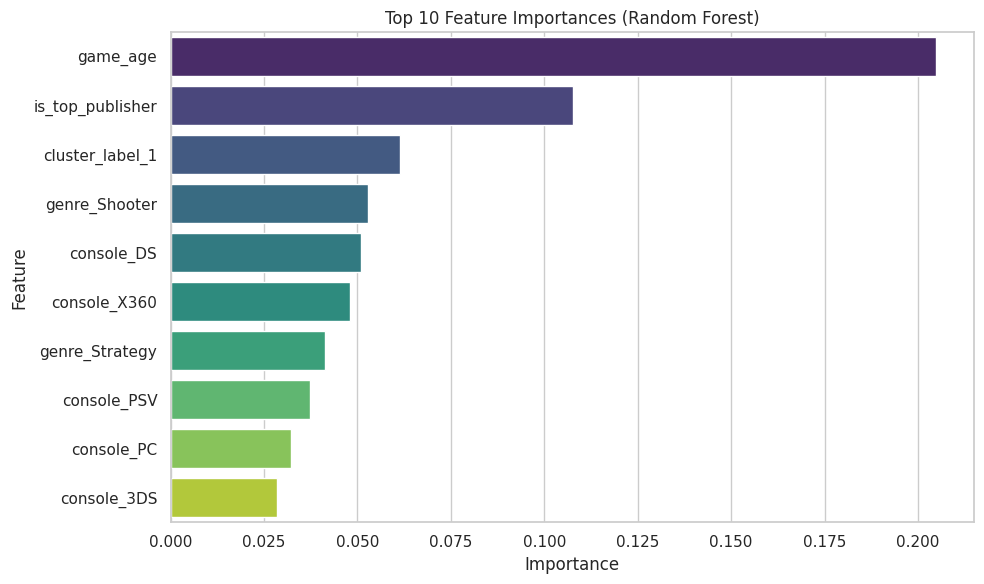

In [17]:
importances = rf_clf.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig("../diagrams/Top 10 Feature Importances (Random Forest).png")
plt.show()


### Learning Curves
We check for overfitting by observing the gap between training and validation scores as the dataset size increases.

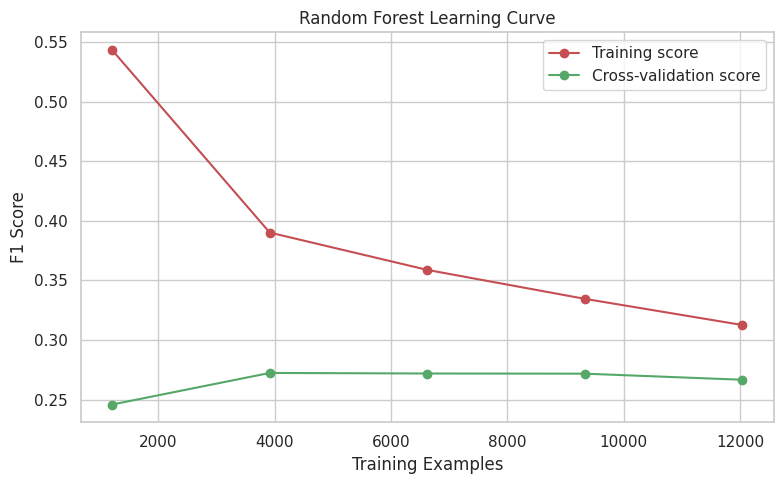

In [18]:
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training Examples")
    plt.ylabel("F1 Score")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(f"../diagrams/learning_curve_{title.replace(' ', '_')}.png")
    plt.show()

# Generating curve for Random Forest
plot_learning_curve(rf_clf, X_train, y_train, "Random Forest Learning Curve")

### Summary of Improvements

The integration of ensemble methods and cluster labels led to a noticeable change in performance metrics. While Accuracy remained relatively stable, the **F1 Score** showed a slight improvement when moving from the Logistic Regression baseline to the Random Forest model. 

The **feature importance plot** reveals that `game_age` and certain `console` types are the strongest predictors of success. Interestingly, the `cluster_label` features did provide some predictive value, confirming that the "era" or "platform ecosystem" of a game (identified in Task 3) correlates with its commercial performance. 

However, the **learning curves** indicate that while the model isn't severely overfitting (the gap between curves is manageable), the F1 score plateaus early. This suggests that the current features (metadata only) have a "theoretical ceiling" for prediction. To achieve significantly higher accuracy, we would likely need more granular data such as marketing spend, critic scores (which were largely missing), or pre-release social media hype.